# 🌫️ Kathmandu Air Quality & Health Analysis
## Notebook 01: Data Acquisition

**Goal:** Collect air quality, weather, and health proxy data for Kathmandu.

### Data Sources:
| Source | Data | Format |
|--------|------|--------|
| OpenAQ | PM2.5, PM10, NO2, O3 | API |
| Open-Meteo | Temperature, Humidity, Wind | API |
| Google Trends | Health search keywords | CSV |

**Date Range:** 2020–2024  
**Location:** Kathmandu, Nepal (lat: 27.7172, lon: 85.3240)

In [1]:
# Run this once to install all required libraries
!pip install requests pandas numpy matplotlib seaborn pytrends

In [16]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import json  # ← make sure this is here



# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [17]:
# Create project folders if they don't exist
folders = ["data/raw", "data/processed"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"📁 Ready: {folder}")

📁 Ready: data/raw
📁 Ready: data/processed


## 🔄 Switching to Open-Meteo Air Quality API
WAQI Kathmandu stations are currently unreachable.
Open-Meteo provides reliable historical air quality + weather data for any coordinates.
No API key required.

In [23]:
import requests
import pandas as pd

def fetch_openmeteo_airquality(start_date="2020-01-01", end_date="2024-12-31"):
    """
    Fetch historical air quality data for Kathmandu from Open-Meteo.
    Completely free, no API key needed.
    """
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    
    params = {
        "latitude": 27.7172,
        "longitude": 85.3240,
        "hourly": "pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,ozone,dust,uv_index",
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "Asia/Kathmandu"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    df = pd.DataFrame(data["hourly"])
    df.rename(columns={"time": "datetime"}, inplace=True)
    df["datetime"] = pd.to_datetime(df["datetime"])
    
    return df

# Test it
print("Fetching air quality data for Kathmandu...")
aq_df = fetch_openmeteo_airquality()
print(f"✅ Got {len(aq_df)} hourly records")
print(f"Date range: {aq_df['datetime'].min()} → {aq_df['datetime'].max()}")
print(f"\nColumns: {list(aq_df.columns)}")
print(f"\nFirst few rows:")
aq_df.head()

Fetching air quality data for Kathmandu...
✅ Got 43848 hourly records
Date range: 2020-01-01 00:00:00 → 2024-12-31 23:00:00

Columns: ['datetime', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone', 'dust', 'uv_index']

First few rows:


,datetime,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,ozone,dust,uv_index
0,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
def fetch_openmeteo_weather(start_date="2020-01-01", end_date="2024-12-31"):
    """
    Fetch historical weather data for Kathmandu from Open-Meteo.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        "latitude": 27.7172,
        "longitude": 85.3240,
        "daily": [
            "temperature_2m_mean",
            "precipitation_sum",
            "windspeed_10m_max",
            "relative_humidity_2m_mean"
        ],
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "Asia/Kathmandu"
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    df = pd.DataFrame(data["daily"])
    df.rename(columns={"time": "date"}, inplace=True)
    df["date"] = pd.to_datetime(df["date"])
    
    return df

print("Fetching weather data for Kathmandu...")
weather_df = fetch_openmeteo_weather()
print(f"✅ Got {len(weather_df)} daily records")
print(f"Date range: {weather_df['date'].min()} → {weather_df['date'].max()}")
print(f"\nFirst few rows:")
weather_df.head()

Fetching weather data for Kathmandu...
✅ Got 1827 daily records
Date range: 2020-01-01 00:00:00 → 2024-12-31 00:00:00

First few rows:


,date,temperature_2m_mean,precipitation_sum,windspeed_10m_max,relative_humidity_2m_mean
0,2020-01-01,9.8,0.0,6.5,63
1,2020-01-02,10.1,0.0,6.5,71
2,2020-01-03,7.7,14.1,8.7,91
3,2020-01-04,7.9,7.0,6.4,88
4,2020-01-05,7.3,0.2,9.1,80


In [25]:
from pytrends.request import TrendReq
import time

def fetch_google_trends():
    """
    Fetch health-related search trends for Nepal as proxy for respiratory health.
    We fetch in yearly chunks to get maximum resolution (weekly data).
    """
    pytrends = TrendReq(hl='en-US', tz=345)
    
    # Keywords related to respiratory health
    keywords = ["cough", "asthma", "breathing problem"]
    
    timeframes = [
        "2020-01-01 2020-12-31",
        "2021-01-01 2021-12-31",
        "2022-01-01 2022-12-31",
        "2023-01-01 2023-12-31",
        "2024-01-01 2024-12-31",
    ]
    
    all_chunks = []
    
    for timeframe in timeframes:
        print(f"  Fetching: {timeframe}")
        try:
            pytrends.build_payload(keywords, geo="NP", timeframe=timeframe)
            df = pytrends.interest_over_time()
            
            if not df.empty:
                if "isPartial" in df.columns:
                    df = df.drop(columns=["isPartial"])
                all_chunks.append(df)
            
            time.sleep(2)  # avoid rate limiting
            
        except Exception as e:
            print(f"  ⚠️ Error for {timeframe}: {e}")
            continue
    
    if all_chunks:
        final_df = pd.concat(all_chunks)
        final_df = final_df[~final_df.index.duplicated(keep='first')]
        final_df.reset_index(inplace=True)
        final_df.rename(columns={"date": "week"}, inplace=True)
        return final_df
    else:
        return None

print("Fetching Google Trends health data for Nepal...")
trends_df = fetch_google_trends()

if trends_df is not None:
    print(f"✅ Got {len(trends_df)} weekly records")
    print(f"Date range: {trends_df['week'].min()} → {trends_df['week'].max()}")
    print(f"\nFirst few rows:")
    print(trends_df.head())
else:
    print("❌ Could not fetch trends data")

Fetching Google Trends health data for Nepal...
  Fetching: 2020-01-01 2020-12-31
  Fetching: 2021-01-01 2021-12-31
  Fetching: 2022-01-01 2022-12-31
  Fetching: 2023-01-01 2023-12-31
  Fetching: 2024-01-01 2024-12-31
✅ Got 262 weekly records
Date range: 2019-12-29 00:00:00 → 2024-12-29 00:00:00

First few rows:
        week  cough  asthma  breathing problem
0 2019-12-29     42      21                  0
1 2020-01-05     45      12                  0
2 2020-01-12     38      12                  0
3 2020-01-19     37      21                  0
4 2020-01-26     48      16                  0


In [26]:
# Save all three datasets to raw folder
aq_df.to_csv("data/raw/kathmandu_airquality.csv", index=False)
print(f"✅ Saved air quality: {aq_df.shape[0]} rows × {aq_df.shape[1]} cols")

weather_df.to_csv("data/raw/kathmandu_weather.csv", index=False)
print(f"✅ Saved weather: {weather_df.shape[0]} rows × {weather_df.shape[1]} cols")

trends_df.to_csv("data/raw/nepal_health_trends.csv", index=False)
print(f"✅ Saved health trends: {trends_df.shape[0]} rows × {trends_df.shape[1]} cols")

print("\n📁 All raw data saved to data/raw/")
print("We will never need to fetch this data again!")

✅ Saved air quality: 43848 rows × 8 cols
✅ Saved weather: 1827 rows × 5 cols
✅ Saved health trends: 262 rows × 4 cols

📁 All raw data saved to data/raw/
We will never need to fetch this data again!


## 📊 Phase 1 Summary — Quick Data Preview
A quick look at what we collected before moving to cleaning.

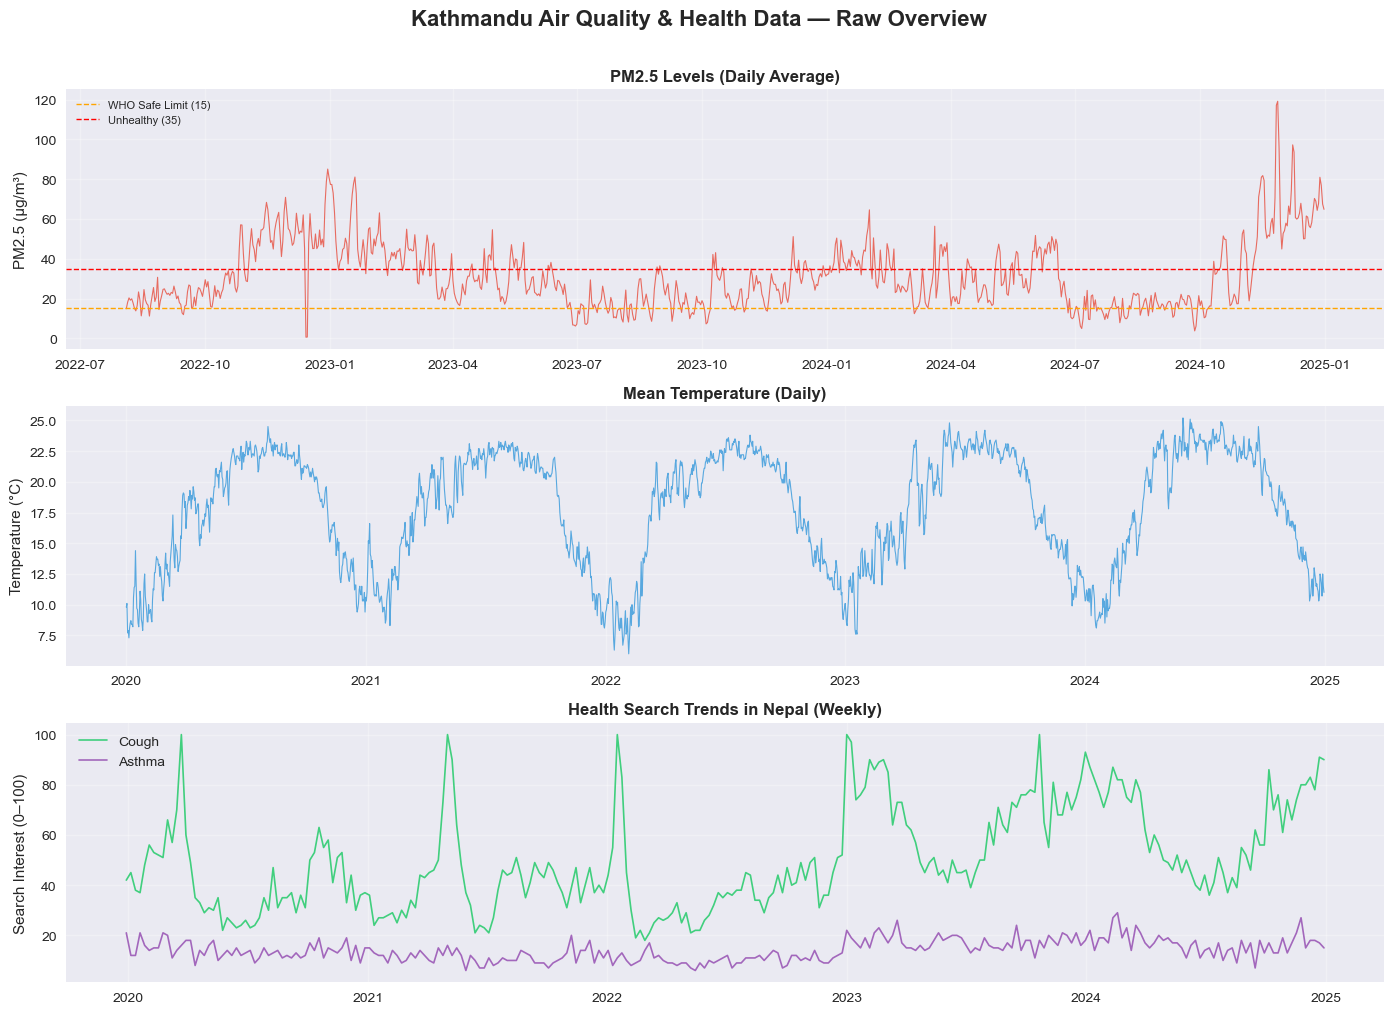

✅ Preview chart saved to data/raw/phase1_preview.png


In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Kathmandu Air Quality & Health Data — Raw Overview", 
             fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: PM2.5 over time ---
aq_daily = aq_df.copy()
aq_daily["date"] = aq_daily["datetime"].dt.date
aq_daily = aq_daily.groupby("date")["pm2_5"].mean().reset_index()

axes[0].plot(pd.to_datetime(aq_daily["date"]), aq_daily["pm2_5"], 
             color="#e74c3c", linewidth=0.8, alpha=0.8)
axes[0].set_title("PM2.5 Levels (Daily Average)", fontweight='bold')
axes[0].set_ylabel("PM2.5 (μg/m³)")
axes[0].axhline(y=15, color='orange', linestyle='--', linewidth=1, label="WHO Safe Limit (15)")
axes[0].axhline(y=35, color='red', linestyle='--', linewidth=1, label="Unhealthy (35)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Temperature over time ---
axes[1].plot(weather_df["date"], weather_df["temperature_2m_mean"], 
             color="#3498db", linewidth=0.8, alpha=0.8)
axes[1].set_title("Mean Temperature (Daily)", fontweight='bold')
axes[1].set_ylabel("Temperature (°C)")
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Google Trends ---
axes[2].plot(trends_df["week"], trends_df["cough"], 
             color="#2ecc71", linewidth=1.2, label="Cough", alpha=0.9)
axes[2].plot(trends_df["week"], trends_df["asthma"], 
             color="#9b59b6", linewidth=1.2, label="Asthma", alpha=0.9)
axes[2].set_title("Health Search Trends in Nepal (Weekly)", fontweight='bold')
axes[2].set_ylabel("Search Interest (0–100)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/raw/phase1_preview.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Preview chart saved to data/raw/phase1_preview.png")